# Waze User Churn Prediction
## MSIN0097 Predictive Analytics — Individual Coursework


## 0. Setup & Imports

In [37]:
!pip install --upgrade scikit-learn
!pip install xgboost
!pip install shap

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

import shap
from scipy import stats

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded successfully')

Libraries loaded successfully


In [39]:
# --- Automated Directory Setup ---
import os

# Create necessary directories if they don't exist to ensure reproducibility
# This prevents FileNotFoundError when saving plots or models
directories = ['../figures', '../models']
for folder in directories:
    if not os.path.exists(folder):
        os.makedirs(folder)
        print(f"Created directory: {folder}")

## 1. Obtain a dataset and frame the predictive problem


### 1. Problem Definition & Business Context
**Goal:** To identify users at risk of churning in the subsequent month based on their current usage patterns. Early identification enables the business to deploy targeted retention strategies (e.g., push notifications or incentives) to minimize revenue loss.

* **Prediction Type:** Supervised Binary Classification
* **Target Variable:** The `label` column.
    * **Positive Class (1):** `churned`
    * **Negative Class (0):** `retained`

### 2. Success Metrics & Constraints
* **Primary Metric: F1-Score **
* **Secondary Metric: ROC-AUC,PR-AUC**
* **Constraints:**
    * **Interpretability:** : The final model should be explainable to non-technical stakeholders. I prioritise transparent models (e.g., Logistic Regression) where effects can be communicated via coefficients/odds ratios. For more complex models explored during shortlisting (e.g., XGBoost), I use SHAP as a supplementary tool to describe feature influence and sanity-check model behaviour.
    * **Data Leakage:** Features must reflect information available at the prediction time (current month). I keep strict train/validation/test split discipline with preprocessing fitted only on training folds to avoid leakage through scaling and imputation.


### 3. Assumptions & Limitations
* **Assumptions:** 
Past user behaviors such as driven kilometers, sessions reflect engagement and can help predict whether a user will be active next month.
Churn is defined as zero app activity in the final month of the observation window.
* **Limitations:** 
    - Snapshot data: Features are monthly aggregates, so I cannot observe within-month sequences (e.g., sudden drop-offs), which may hide early churn signals.
    - Unobserved factors: External events (marketing, seasonality, competitor actions) are not in the dataset, so the model cannot separate these effects from user behaviour.
    - Prediction is not equal with causality: Even if a feature is predictive, it does not mean changing it will cause retention to improve.

### 4. Agent Collaboration Strategy
* **Role of the Agent:** I used an AI agent as a coding assistant to speed up routine parts of the workflow, but I kept responsibility for correctness and decisions. This follows the “plan → delegate → verify → revise” expectation in the coursework brief.
* **What I delegated to the agent:** draft code for preprocessing pipelines, baseline models, and plotting.
* **What I verified myself:** 
    - Data split discipline (train/validation/test) and no leakage features were included.
    - Metrics and evaluation logic matched the problem setup (minority-class performance is the focus).
    - Agent-generated code was reviewed and run end-to-end before being used.
* **How I revised:**  when the agent suggested an incorrect evaluation or tuning setup, I corrected it and documented the change (see the Fine-Tuning section and the AI Agent Log).



In [40]:
# --- Section 1: Obtain Dataset (Updated) ---
import sys
import os

# 1. Ensure Python can find the 'src' directory
# Get the current notebook directory and move one level up to find project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# 2. Import modules from src
from src.data_loader import load_raw_data, load_and_prepare

# 3. Load raw data (for EDA analysis)
# We use 'load_raw_data' here to keep the original format for visualization
file_path = os.path.join(project_root, 'data/waze_dataset.csv')
df = load_raw_data(file_path)

print(f"Data loaded for EDA. Shape: {df.shape}")
display(df.head())

Data loaded for EDA. Shape: (14999, 13)


,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [41]:
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print(f'\nTarget distribution:')
print(df['label'].value_counts(normalize=True).round(3))

ID                           int64
label                       object
sessions                     int64
drives                       int64
total_sessions             float64
n_days_after_onboarding      int64
total_navigations_fav1       int64
total_navigations_fav2       int64
driven_km_drives           float64
duration_minutes_drives    float64
activity_days                int64
driving_days                 int64
device                      object
dtype: object

Missing values:
ID                           0
label                      700
sessions                     0
drives                       0
total_sessions               0
n_days_after_onboarding      0
total_navigations_fav1       0
total_navigations_fav2       0
driven_km_drives             0
duration_minutes_drives      0
activity_days                0
driving_days                 0
device                       0
dtype: int64

Target distribution:
label
retained    0.823
churned     0.177
Name: proportion, dtype: float64


## 2. Explore the data to gain insights

**Agent contribution:** Claude produced an initial EDA skeleton (class distribution, feature histograms by churn status, correlation heatmap, and missingness checks).

**My verification:** I reran the plots, tests and checked that the numbers match the outputs. Where something was unclear, I added extra plots to answer a specific question:
- Boxplot + histogram for driven_km_drives (the distribution is heavily right-skewed)
- Missing label check by device to see whether the 700 unlabeled rows cluster in one group
- Churn rate vs driving_days to quantify how churn changes with driving frequency
- iPhone vs Android comparison to test whether device type meaningfully affects churn

Missing label group : 700 rows
Known label group   : 14,299 rows

Device Distribution Comparison:
         Missing_count  Known_count  Missing_%  Known_%  Diff_%
device                                                         
iPhone             447         9225      63.86    64.52   -0.66
Android            253         5074      36.14    35.48    0.66

--- Chi-Square Test ---
Chi2 statistic : 0.0990
Degrees of freedom: 1
p-value        : 0.7530

Conclusion: No significant difference (consistent with MAR) at α=0.05


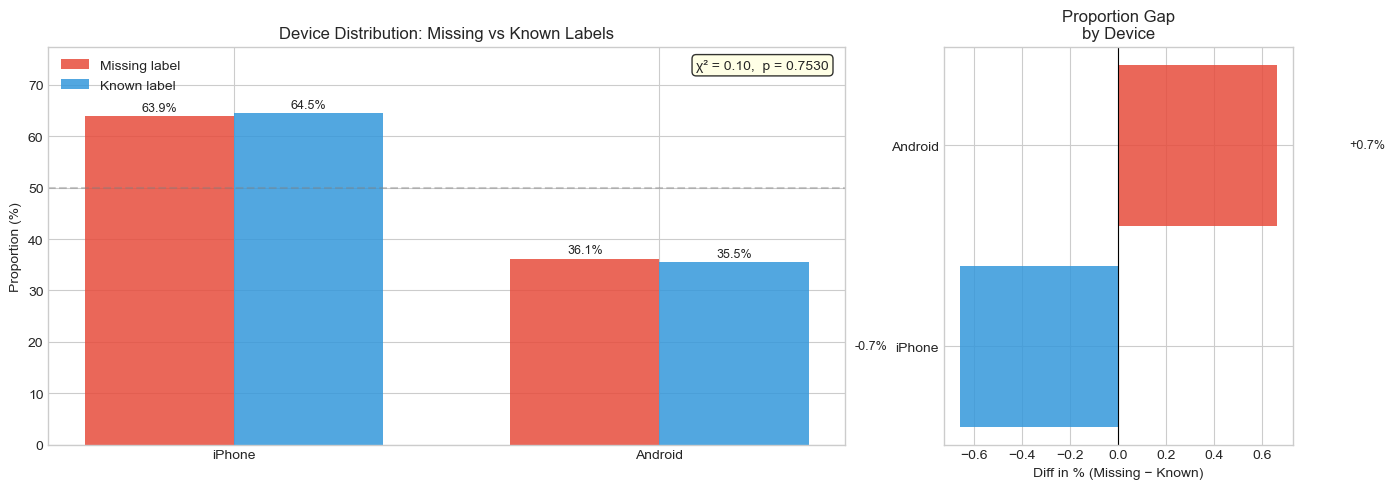


Plot saved as 'device_missing_label_analysis.png'


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import chi2_contingency

# --- Split into missing vs known label groups ---
df_missing = df[df['label'].isna()]
df_known   = df[df['label'].notna()]

print(f"Missing label group : {len(df_missing):,} rows")
print(f"Known label group   : {len(df_known):,} rows\n")

# --- Device distribution (counts + proportions) ---
device_missing = df_missing['device'].value_counts()
device_known   = df_known['device'].value_counts()

summary = pd.DataFrame({
    'Missing_count' : device_missing,
    'Known_count'   : device_known,
}).fillna(0).astype(int)

summary['Missing_%'] = (summary['Missing_count'] / summary['Missing_count'].sum() * 100).round(2)
summary['Known_%']   = (summary['Known_count']   / summary['Known_count'].sum()   * 100).round(2)
summary['Diff_%']    = (summary['Missing_%'] - summary['Known_%']).round(2)

print("Device Distribution Comparison:")
print(summary.to_string())

# --- Chi-square test of independence ---
contingency = summary[['Missing_count', 'Known_count']].values
chi2, p_val, dof, expected = chi2_contingency(contingency)

print(f"\n--- Chi-Square Test ---")
print(f"Chi2 statistic : {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value        : {p_val:.4f}")
print(f"\nConclusion: {'SIGNIFICANT difference (NOT missing at random)' if p_val < 0.05 else 'No significant difference (consistent with MAR)'} "
      f"at α=0.05")

# --- Visualisation ---
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

devices = summary.index.tolist()
x       = np.arange(len(devices))
width   = 0.35
colors  = {'Missing': '#E74C3C', 'Known': '#3498DB'}

# Subplot 1 — grouped bar (proportions)
ax1 = fig.add_subplot(gs[0, :2])
bars1 = ax1.bar(x - width/2, summary['Missing_%'], width, label='Missing label', color=colors['Missing'], alpha=0.85)
bars2 = ax1.bar(x + width/2, summary['Known_%'],   width, label='Known label',   color=colors['Known'],   alpha=0.85)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax1.set_xticks(x)
ax1.set_xticklabels(devices)
ax1.set_ylabel('Proportion (%)')
ax1.set_title('Device Distribution: Missing vs Known Labels')
ax1.legend()
ax1.set_ylim(0, max(summary[['Missing_%','Known_%']].values.max() * 1.2, 10))
ax1.axhline(y=50, color='gray', linestyle='--', alpha=0.4, label='50% line')
p_text = f'χ² = {chi2:.2f},  p = {p_val:.4f}'
ax1.text(0.98, 0.97, p_text, transform=ax1.transAxes, ha='right', va='top',
         fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Subplot 2 — difference bar
ax2 = fig.add_subplot(gs[0, 2])
diff_colors = ['#E74C3C' if d > 0 else '#3498DB' for d in summary['Diff_%']]
ax2.barh(devices, summary['Diff_%'], color=diff_colors, alpha=0.85)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Diff in % (Missing − Known)')
ax2.set_title('Proportion Gap\nby Device')
for i, (v, dev) in enumerate(zip(summary['Diff_%'], devices)):
    ax2.text(v + (0.3 if v >= 0 else -0.3), i, f'{v:+.1f}%',
             va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('device_missing_label_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as 'device_missing_label_analysis.png'")

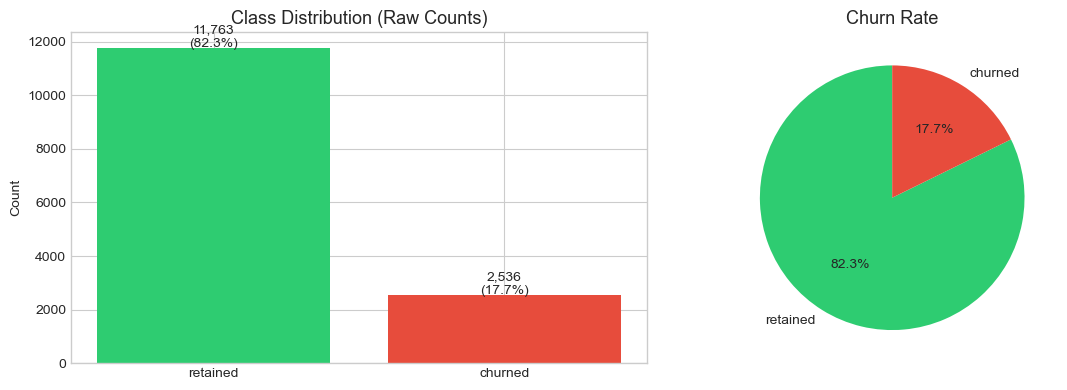

Imbalance ratio: 4.64:1


In [65]:
# --- Class Distrubution --
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['label'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution (Raw Counts)', fontsize=13)
axes[0].set_ylabel('Count')
total_labelled = churn_counts.values.sum()  # 14,299 — labelled rows only
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/total_labelled*100:.1f}%)', ha='center')  # ✅

# Pie
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Rate', fontsize=13)
plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Imbalance ratio: {churn_counts[0]/churn_counts[1]:.2f}:1')

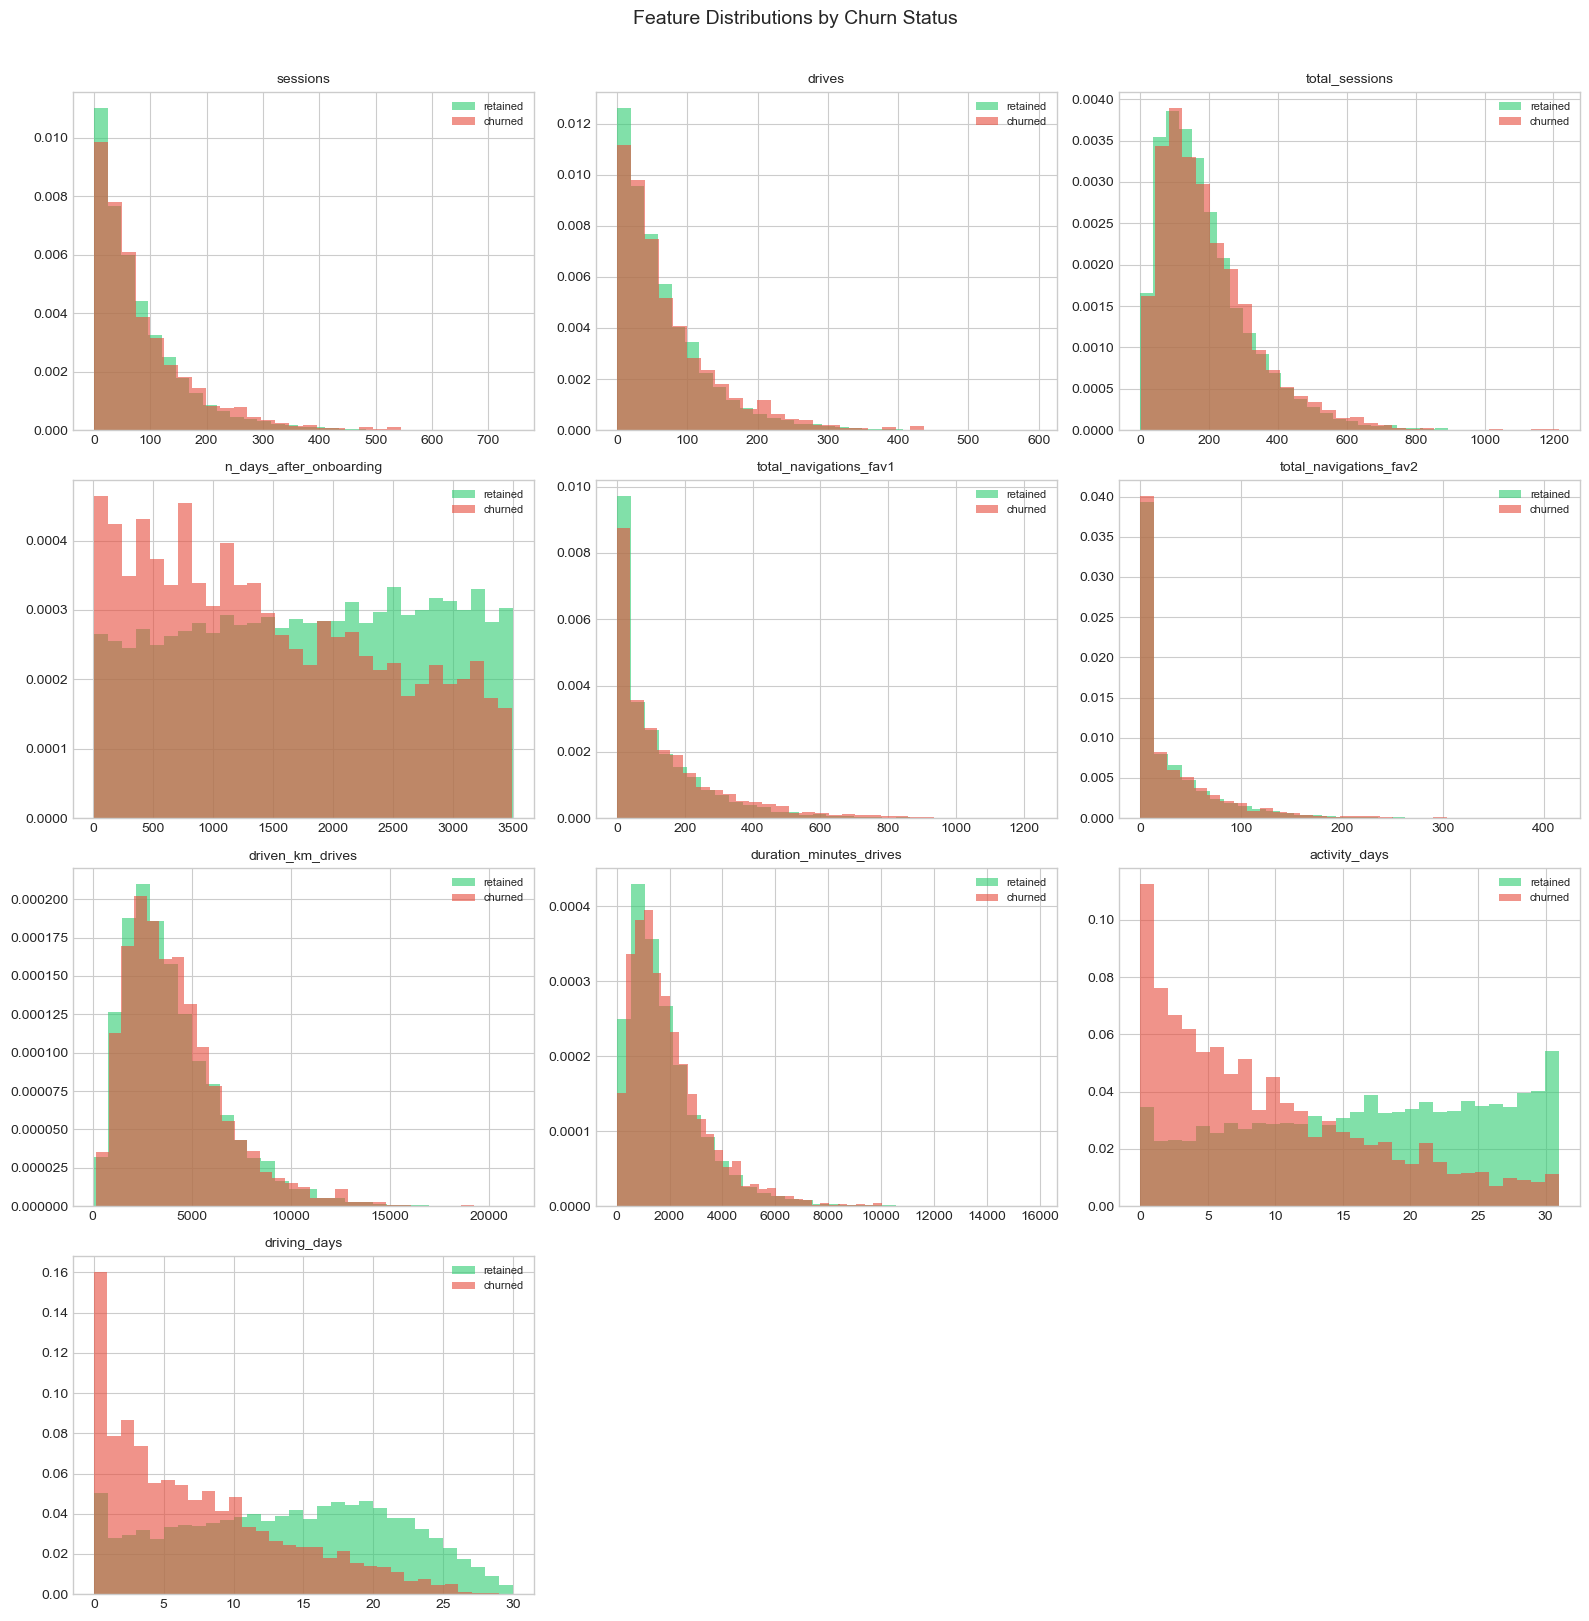

In [66]:
# --- Feature distributions by churn status ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns 
                if c not in ['ID', 'churn_numeric']]

n = len(numeric_cols)
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(16, 16))
axes = axes.flatten() 

for i, col in enumerate(numeric_cols):
    for label, color in [('retained', '#2ecc71'), ('churned', '#e74c3c')]:
        subset = df[df['label'] == label][col].dropna()
        axes[i].hist(subset, alpha=0.6, label=label, color=color, bins=30, density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)



plt.suptitle('Feature Distributions by Churn Status', fontsize=14, y=1.01)
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig('02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

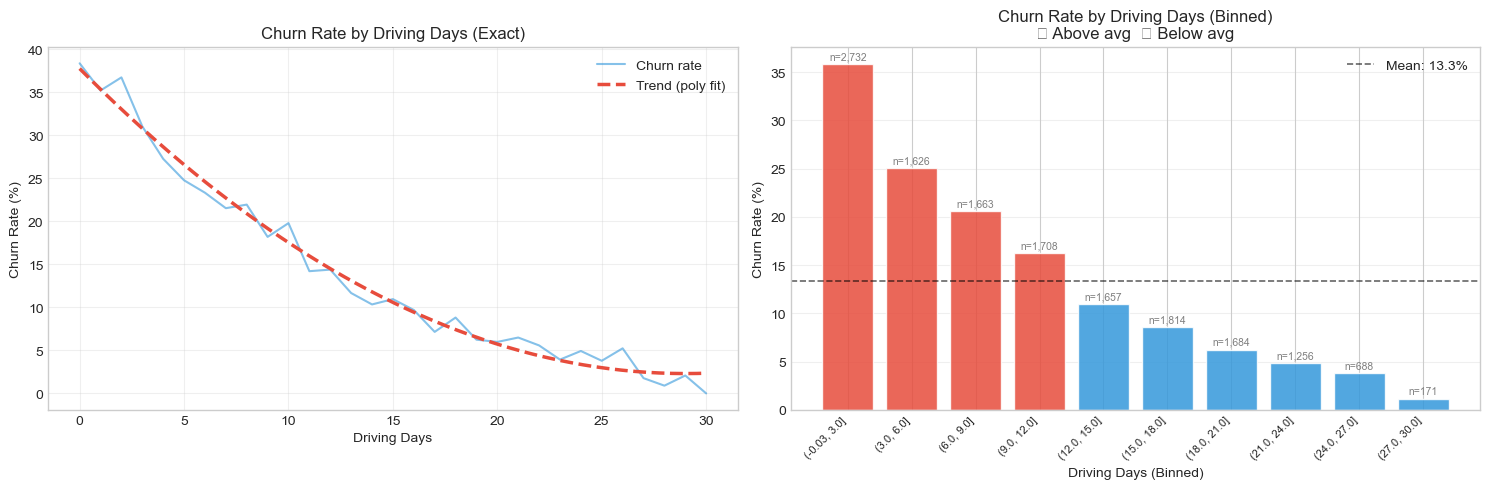

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Fix 1: Create numeric churn column from string labels ---
df['churn_numeric'] = (df['label'] == 'churned').astype(int)

# --- Fix 2: Use df instead of df_clean ---
churn_by_days = df.groupby('driving_days')['churn_numeric'].agg(['mean', 'count']).reset_index()
churn_by_days.columns = ['driving_days', 'churn_rate', 'count']
churn_by_days['churn_rate_pct'] = churn_by_days['churn_rate'] * 100

# --- Binned version ---
df['driving_days_bin'] = pd.cut(df['driving_days'], bins=10)
churn_by_bin = df.groupby('driving_days_bin', observed=True)['churn_numeric'].agg(['mean', 'count']).reset_index()
churn_by_bin['churn_rate_pct'] = churn_by_bin['mean'] * 100
bin_labels = [str(b) for b in churn_by_bin['driving_days_bin']]

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Line plot (exact driving_days)
ax1 = axes[0]
ax1.plot(churn_by_days['driving_days'], churn_by_days['churn_rate_pct'],
         color='#3498DB', linewidth=1.5, alpha=0.6, label='Churn rate')

z = np.polyfit(churn_by_days['driving_days'], churn_by_days['churn_rate_pct'], 2)
p = np.poly1d(z)
x_smooth = np.linspace(churn_by_days['driving_days'].min(), churn_by_days['driving_days'].max(), 200)
ax1.plot(x_smooth, p(x_smooth), color='#E74C3C', linewidth=2.5, linestyle='--', label='Trend (poly fit)')

ax1.set_xlabel('Driving Days')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_title('Churn Rate by Driving Days (Exact)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Binned bar chart
ax2 = axes[1]
mean_churn = churn_by_bin['churn_rate_pct'].mean()
bar_colors = ['#E74C3C' if v > mean_churn else '#3498DB' for v in churn_by_bin['churn_rate_pct']]
bars = ax2.bar(range(len(bin_labels)), churn_by_bin['churn_rate_pct'],
               color=bar_colors, alpha=0.85, edgecolor='white')

for bar, n in zip(bars, churn_by_bin['count']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'n={n:,}', ha='center', va='bottom', fontsize=7.5, color='gray')

ax2.axhline(mean_churn, color='black', linestyle='--', linewidth=1.2, alpha=0.6,
            label=f'Mean: {mean_churn:.1f}%')
ax2.set_xticks(range(len(bin_labels)))
ax2.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=8)
ax2.set_xlabel('Driving Days (Binned)')
ax2.set_ylabel('Churn Rate (%)')
ax2.set_title('Churn Rate by Driving Days (Binned)\n🔴 Above avg  🔵 Below avg')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('churn_by_driving_days.png', dpi=150, bbox_inches='tight')
plt.show()

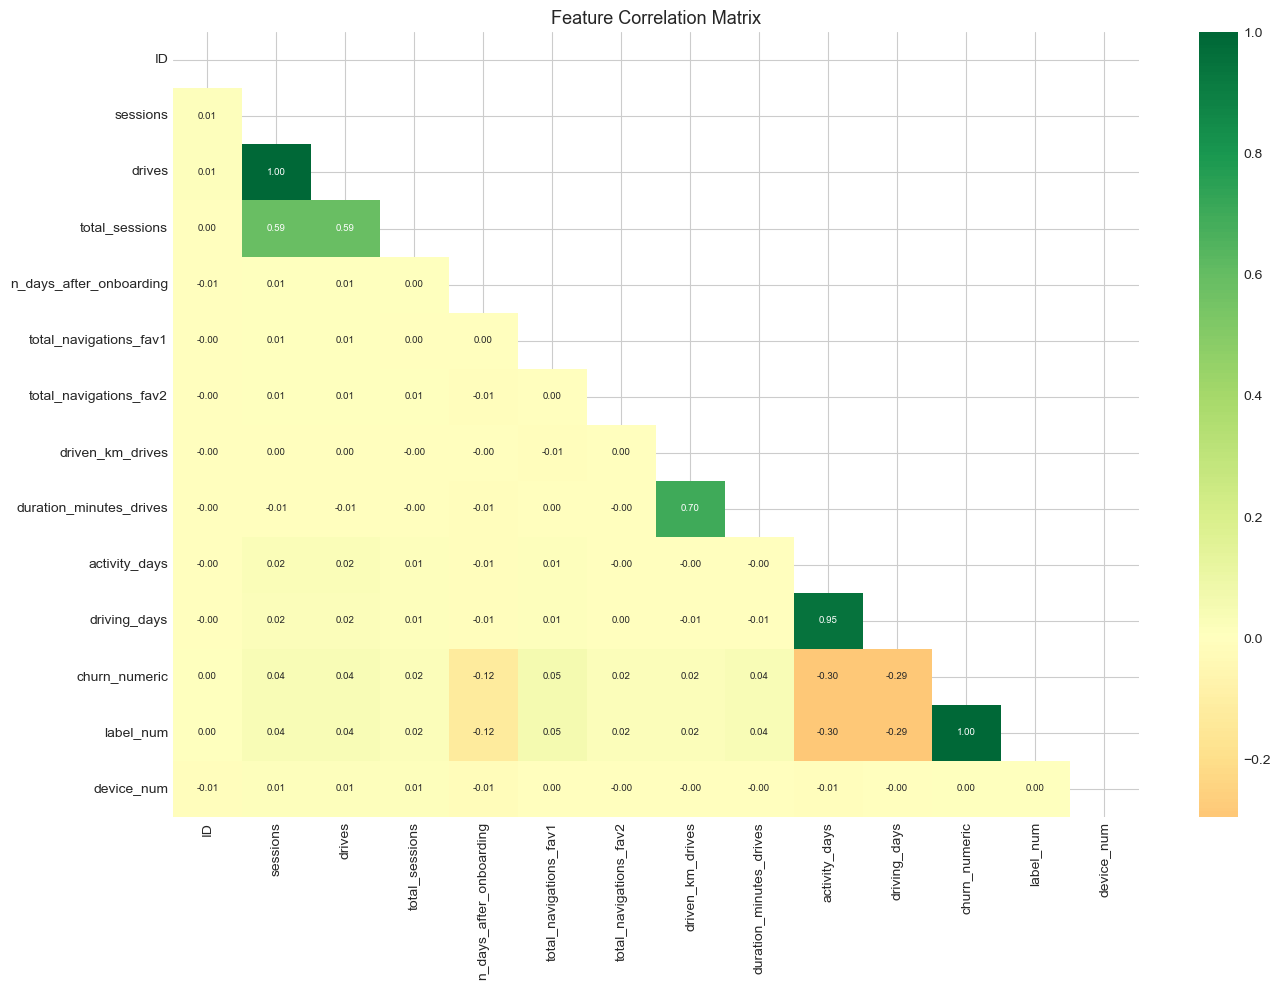

In [68]:
# --- Correlation heatmap (numeric features only) ---
# LEAKAGE CHECK: confirm no target-derived features in correlation
df_encoded = df.copy()
df_encoded['label_num'] = (df_encoded['label'] == 'churned').astype(int)
df_encoded['device_num'] = (df_encoded['device'] == 'iPhone').astype(int)

corr_cols = [c for c in df_encoded.select_dtypes(include=[np.number]).columns]
corr_matrix = df_encoded[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [69]:
# --- Outlier detection ---
print('=== Outlier Detection (Z-score > 3) ===')
for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    n_outliers = (z_scores > 3).sum()
    if n_outliers > 0:
        print(f'{col}: {n_outliers} outliers ({n_outliers/len(df)*100:.1f}%)')

=== Outlier Detection (Z-score > 3) ===
sessions: 284 outliers (1.9%)
drives: 275 outliers (1.8%)
total_sessions: 222 outliers (1.5%)
total_navigations_fav1: 302 outliers (2.0%)
total_navigations_fav2: 318 outliers (2.1%)
driven_km_drives: 206 outliers (1.4%)
duration_minutes_drives: 272 outliers (1.8%)


=== Outlier Summary: driven_km_drives ===
Q1        : 2,212.60
Q3        : 5,289.86
IQR       : 3,077.26
Lower fence: -2,403.29
Upper fence: 9,905.75
Outliers  : 463 rows (3.1% of data)


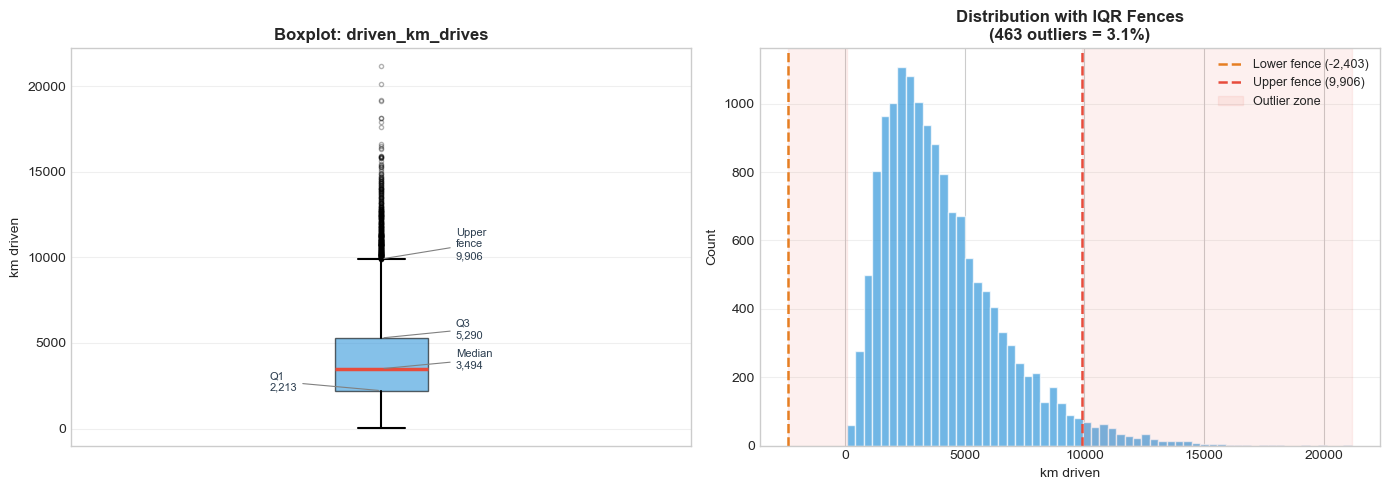

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

col = 'driven_km_drives'

# --- Outlier stats ---
Q1  = df[col].quantile(0.25)
Q3  = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df[col] < lower) | (df[col] > upper)]

print(f"=== Outlier Summary: {col} ===")
print(f"Q1        : {Q1:,.2f}")
print(f"Q3        : {Q3:,.2f}")
print(f"IQR       : {IQR:,.2f}")
print(f"Lower fence: {lower:,.2f}")
print(f"Upper fence: {upper:,.2f}")
print(f"Outliers  : {len(outliers):,} rows ({len(outliers)/len(df)*100:.1f}% of data)")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Boxplot
ax1 = axes[0]
bp = ax1.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#3498DB', alpha=0.6),
                 medianprops=dict(color='#E74C3C', linewidth=2.5),
                 flierprops=dict(marker='o', color='#E74C3C', alpha=0.3, markersize=3),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))

# Annotate key values
for label, val, offset in [('Q1',     Q1,                -0.18),
                             ('Median', df[col].median(),  0.12),
                             ('Q3',     Q3,                0.12),
                             ('Upper\nfence', upper,       0.12)]:
    ax1.annotate(f'{label}\n{val:,.0f}',
                 xy=(1, val), xytext=(1 + offset, val),
                 fontsize=8, color='#2C3E50',
                 arrowprops=dict(arrowstyle='-', color='gray', lw=0.8))

ax1.set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
ax1.set_ylabel('km driven')
ax1.set_xticks([])
ax1.grid(True, alpha=0.3, axis='y')

# Right — Distribution with outlier zones shaded
ax2 = axes[1]
ax2.hist(df[col].dropna(), bins=60, color='#3498DB', alpha=0.7, edgecolor='white')
ax2.axvline(lower, color='#E67E22', linestyle='--', linewidth=1.8, label=f'Lower fence ({lower:,.0f})')
ax2.axvline(upper, color='#E74C3C', linestyle='--', linewidth=1.8, label=f'Upper fence ({upper:,.0f})')
ax2.axvspan(df[col].min(), lower, alpha=0.08, color='#E74C3C', label='Outlier zone')
ax2.axvspan(upper, df[col].max(), alpha=0.08, color='#E74C3C')
ax2.set_xlabel('km driven')
ax2.set_ylabel('Count')
ax2.set_title(f'Distribution with IQR Fences\n({len(outliers):,} outliers = {len(outliers)/len(df)*100:.1f}%)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outliers_driven_km_drives.png', dpi=150, bbox_inches='tight')
plt.show()

=== Churn Rate by Device ===
 device  churned  total  churn_rate_pct
Android      891   5327       16.726112
 iPhone     1645   9672       17.007858

=== Statistical Tests ===
Chi-Square : χ²=0.1746, p=0.6761, dof=1
Z-Test     : z=0.4406, p=0.6595

Conclusion : ❌ NOT significant difference at α=0.05


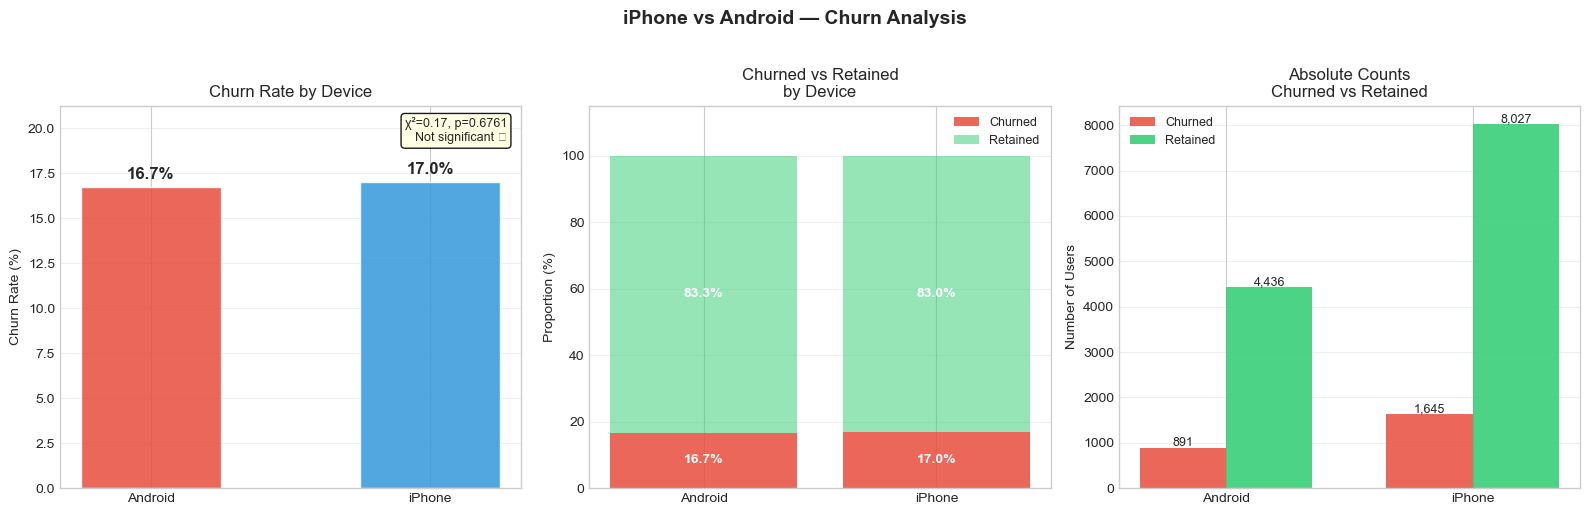

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest  # ✅ correct source

# --- Ensure numeric churn column exists ---
df['churn_numeric'] = (df['label'] == 'churned').astype(int)

# --- Summary stats by device ---
summary = df.groupby('device')['churn_numeric'].agg(['mean', 'sum', 'count']).reset_index()
summary.columns = ['device', 'churn_rate', 'churned', 'total']
summary['churn_rate_pct'] = summary['churn_rate'] * 100
summary['retained'] = summary['total'] - summary['churned']

print("=== Churn Rate by Device ===")
print(summary[['device', 'churned', 'total', 'churn_rate_pct']].to_string(index=False))

# --- Chi-Square Test ---
contingency = summary[['churned', 'retained']].values
chi2, p_chi2, dof, expected = chi2_contingency(contingency)

# --- Z-Test for proportions ---
iphone_row  = summary[summary['device'] == 'iPhone'].iloc[0]
android_row = summary[summary['device'] == 'Android'].iloc[0]

count  = np.array([iphone_row['churned'],  android_row['churned']])
nobs   = np.array([iphone_row['total'],    android_row['total']])
z_stat, p_ztest = proportions_ztest(count, nobs)

print(f"\n=== Statistical Tests ===")
print(f"Chi-Square : χ²={chi2:.4f}, p={p_chi2:.4f}, dof={dof}")
print(f"Z-Test     : z={z_stat:.4f}, p={p_ztest:.4f}")
sig = p_chi2 < 0.05
print(f"\nConclusion : {'✅ SIGNIFICANT' if sig else '❌ NOT significant'} difference at α=0.05")

# ── Visualisation ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'iPhone': '#3498DB', 'Android': '#E74C3C'}
devices = summary['device'].tolist()
bar_colors = [colors.get(d, '#95A5A6') for d in devices]

# Panel 1 — Churn rate bar chart
ax1 = axes[0]
bars = ax1.bar(devices, summary['churn_rate_pct'], color=bar_colors, alpha=0.85,
               edgecolor='white', width=0.5)
for bar, val in zip(bars, summary['churn_rate_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_title('Churn Rate by Device')
ax1.set_ylim(0, summary['churn_rate_pct'].max() * 1.25)
ax1.grid(True, alpha=0.3, axis='y')
p_text = f'χ²={chi2:.2f}, p={p_chi2:.4f}\n{"Significant ✅" if sig else "Not significant ❌"}'
ax1.text(0.97, 0.97, p_text, transform=ax1.transAxes, ha='right', va='top',
         fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# Panel 2 — Stacked bar (churned vs retained proportions)
ax2 = axes[1]
churn_pcts    = summary['churn_rate_pct'].values
retained_pcts = 100 - churn_pcts
x = np.arange(len(devices))
b1 = ax2.bar(x, churn_pcts,    color=['#E74C3C','#E74C3C'], alpha=0.85, label='Churned')
b2 = ax2.bar(x, retained_pcts, bottom=churn_pcts, color=['#2ECC71','#2ECC71'], alpha=0.5, label='Retained')
for i, (c, r) in enumerate(zip(churn_pcts, retained_pcts)):
    ax2.text(i, c/2,       f'{c:.1f}%', ha='center', va='center', fontsize=10, color='white', fontweight='bold')
    ax2.text(i, c + r/2,   f'{r:.1f}%', ha='center', va='center', fontsize=10, color='white', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(devices)
ax2.set_ylabel('Proportion (%)')
ax2.set_title('Churned vs Retained\nby Device')
ax2.legend(loc='upper right', fontsize=9)
ax2.set_ylim(0, 115)
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3 — Absolute counts grouped bar
ax3 = axes[2]
w = 0.35
x = np.arange(len(devices))
ax3.bar(x - w/2, summary['churned'],  width=w, color='#E74C3C', alpha=0.85, label='Churned')
ax3.bar(x + w/2, summary['retained'], width=w, color='#2ECC71', alpha=0.85, label='Retained')
for i, row in summary.iterrows():
    ax3.text(i - w/2, row['churned']  + 30, f"{int(row['churned']):,}",  ha='center', fontsize=9)
    ax3.text(i + w/2, row['retained'] + 30, f"{int(row['retained']):,}", ha='center', fontsize=9)
ax3.set_xticks(x)
ax3.set_xticklabels(devices)
ax3.set_ylabel('Number of Users')
ax3.set_title('Absolute Counts\nChurned vs Retained')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

plt.suptitle('iPhone vs Android — Churn Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_by_device.png', dpi=150, bbox_inches='tight')
plt.show()

### Key EDA Findings

**1. Missing Values** A chi-square test shows no evidence that missing labels are associated with device type (p = 0.753). I drop these unlabeled rows for modelling, but note this does not rule out missingness patterns in other features.

**2. Class Imbalance**
The dataset has 82.3% retained users and 17.7% churned users (imbalance ratio 4.64:1). This means accuracy is not a useful metric.A model that always predicts "retained" would achieve 82.3% accuracy while identifying zero churners.Therefore,F1-score is used as the primary metric instead (and also monitor ROC-AUC / PR-AUC).

**3. Activity Days & Driving Days**
Churned users tend to have fewer active days and driving days in the month. Most churned users were only active for 0–10 days, while retained users are 
spread more evenly across the full 30-day range.

**4. Churn Rate by Driving Days**
Users who drove between 0 and 3 days had a churn rate over 35%, more than double the overall churn rate of 17.7%. The more days a user drives, the less 
likely they are to churn.This indicates driving frequency is likely a strong predictor.

**5. Multicollinearity: Activity Days & Driving Days**
activity_days and driving_days are highly correlated (r ≈ 0.95). To reduce redundancy, I will either keep one of them or rely on regularisation.

**6. Outliers in driven_km_drives**
463 rows (3.1%) exceed the IQR upper fence of 9,906 km. This likely reflects heavy users. I will consider robust handling such as log transform or cappingto reduce sensitivity.

**7. Device Type (iPhone vs Android)**
Android users churn: 16.7% vs iPhone users churn: 17.0% ; The difference is not statistically significant (p=0.676). Churn appears to be driven more by behaviour than device.

## 3. Prepare the data
- Feature matrix creation: The agent drafted load_and_prepare() to (i) drop the 700 unlabeled rows and (ii) build the modelling matrix X (16 features) and target y (overall churn rate 0.177). I reran it and checked the printed counts and feature list matched expectations.
- Train/val/test split: The agent proposed a stratified 70/15/15 split. I kept the approach and verified the churn ratio stayed consistent across train/val/test.
- Preprocessing (leakage control): The agent set up an imputer + scaler pipeline. I reviewed it and ensured it is fit on training only and applied to val/test via .transform() (to avoid leaking distribution information).
- Data validation checks: The agent included basic assert checks; I kept them and used them to confirm X/y alignment and no remaining missing values after imputation.

Interaction summary: I asked the agent to modularise feature engineering into data_loader.py and draft a basic preprocessing pipeline. I reviewed the script and kept the engineered features (+1 denominators to avoid zero division) while confirming ID/label/device/label_num are excluded from X. Evidence is logged in the Appendix.



In [50]:
# --- Section 3:Prepare the data ---

# Use the pipeline script to generate the feature matrix in one go.
# This replaces all manual cleaning and feature engineering code above.
# It ensures the logic is modular, testable, and reproducible.
X, y, feature_cols = load_and_prepare(file_path)

print(f"Engineering complete.")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"X shape: {X.shape} | Churn rate: {y.mean():.3f}")

# --- Re-run Split on the clean X and y ---
from sklearn.model_selection import train_test_split

# Maintain the 70/15/15 stratified split as planned
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176, random_state=42, stratify=y_trainval
)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")

[clean_data] Dropped 700 unlabelled rows. Remaining: 14299
[load_and_prepare] Ready — X: (14299, 16), churn rate: 0.177
Engineering complete.
Features (16): ['sessions', 'drives', 'total_sessions', 'n_days_after_onboarding', 'total_navigations_fav1', 'total_navigations_fav2', 'driven_km_drives', 'duration_minutes_drives', 'activity_days', 'driving_days', 'km_per_drive', 'sessions_per_day', 'drives_per_day', 'pct_days_active', 'total_nav_fav', 'is_iphone']
X shape: (14299, 16) | Churn rate: 0.177
Train size: 10014 | Val size: 2140 | Test size: 2145


In [72]:
# --- Preprocessing Pipeline ---

# All numeric — simple pipeline
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Fit on train only — no leakage from val/test
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

print('Preprocessing pipeline fitted on training data only. ✓')
print(f'Processed shape: {X_train_proc.shape}')


# --- Data Validation Checks (Defensive Programming) ---
# Row alignment checks
assert X_train_proc.shape[0] == len(y_train), "Row count mismatch in training set!"
assert X_val_proc.shape[0] == len(y_val), "Row count mismatch in val set!"
assert X_test_proc.shape[0] == len(y_test), "Row count mismatch in test set!"

# No-NaN checks after imputation
assert np.isnan(X_train_proc).sum() == 0, "NaNs still exist in training set!"
assert np.isnan(X_val_proc).sum() == 0, "NaNs still exist in val set!"
assert np.isnan(X_test_proc).sum() == 0, "NaNs still exist in test set!"



Preprocessing pipeline fitted on training data only. ✓
Processed shape: (10014, 16)


## 4. Explore different models and shortlist the best ones

**1. Establishing a Baseline**
* **AI Assistance:** Claude code provided a simple baseline model.
* **My Verification:** I used an “always retained (0)” baseline as a floor: it gives F1(churn)= 0 and ROC-AUC= 0.5. This is the minimum any trained model should beat.
**2. Model Selection & Handling Imbalance**
* **AI Assistance:** Claude suggested comparing four architectures: Logistic Regression (linear), Random Forest (bagging), XGBoost (modern boosting), and MLP (neural network). 
* **My Verification:** I kept this set and checked how class imbalance was handled: class_weight='balanced' for Logistic Regression and Random Forest,and scale_pos_weight for XGBoost (computed from y_train). For MLP, scikit-learn does not provide a class_weight argument, so it was compared under the default training setup.

**3. Model Comparison**
**AI Assistance:** Claude initially generated code that declared a StratifiedKFold object but failed to implement it in the training loop.
* **My Verification:** I pointed out this coding mistake and asked the agent to regenerate the code. However, during the first revision, Claude used outdated syntax (needs_proba=True) that conflicted with the current version of scikit-learn. This caused the PR-AUC metric to silently fail and output NaN ± NaN across all folds. I caught this execution error, pointed it out to Claude, and revised the scoring pipeline to ensure it ran flawlessly.
After the fix, Logistic Regression performed best on the primary metric (F1(churn)=0.441 ± 0.007), while XGBoost was the strongest modern option (F1(churn)= 0.333 ± 0.010). Random Forest and MLP were less competitive on F1 at the default threshold, so I shortlisted Logistic Regression + XGBoost for fine-tuning.



In [52]:
# --- Baseline: Majority Class Classifier ---
majority_pred = np.zeros(len(y_val))
baseline_f1 = 0  # always predicts 0 — F1 for minority class = 0
baseline_auc = 0.5
print(f'Baseline (majority class) — F1(churn): {baseline_f1:.3f}, ROC-AUC: {baseline_auc:.3f}')

Baseline (majority class) — F1(churn): 0.000, ROC-AUC: 0.500


In [53]:
# --- Define model candidates ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # ≈ 4.64

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=200, random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=200, random_state=RANDOM_STATE,
        eval_metric='logloss', verbosity=0
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=300, random_state=RANDOM_STATE
    )
}

print("Models defined:")
for name in models:
    print(f"  - {name}")


Models defined:
  - Logistic Regression
  - Random Forest
  - XGBoost
  - MLP


In [54]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score, average_precision_score
import numpy as np
import pandas as pd

X_trainval = np.vstack([X_train_proc, X_val_proc])
y_trainval = np.concatenate([y_train, y_val])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'roc_auc'  : 'roc_auc',
    'pr_auc'   : make_scorer(average_precision_score, response_method='predict_proba'),  # ✅ fixed
    'f1_churn' : make_scorer(f1_score, pos_label=1)
}

results = {}
for name, model in models.items():
    print(f"Running 5-fold CV for {name}...")
    cv_results = cross_validate(
        model, X_trainval, y_trainval,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    results[name] = {
        'ROC-AUC'     : cv_results['test_roc_auc'].mean(),
        'ROC-AUC std' : cv_results['test_roc_auc'].std(),
        'PR-AUC'      : cv_results['test_pr_auc'].mean(),
        'PR-AUC std'  : cv_results['test_pr_auc'].std(),
        'F1 (churn)'  : cv_results['test_f1_churn'].mean(),
        'F1 std'      : cv_results['test_f1_churn'].std(),
    }
    print(f"  ROC-AUC : {results[name]['ROC-AUC']:.3f} ± {results[name]['ROC-AUC std']:.3f}")
    print(f"  PR-AUC  : {results[name]['PR-AUC']:.3f} ± {results[name]['PR-AUC std']:.3f}")
    print(f"  F1      : {results[name]['F1 (churn)']:.3f} ± {results[name]['F1 std']:.3f}")

results_df = pd.DataFrame(results).T.sort_values('F1 (churn)', ascending=False)
print('\n', results_df.round(3))

Running 5-fold CV for Logistic Regression...
  ROC-AUC : 0.758 ± 0.010
  PR-AUC  : 0.392 ± 0.018
  F1      : 0.441 ± 0.007
Running 5-fold CV for Random Forest...
  ROC-AUC : 0.727 ± 0.015
  PR-AUC  : 0.352 ± 0.020
  F1      : 0.124 ± 0.029
Running 5-fold CV for XGBoost...
  ROC-AUC : 0.688 ± 0.014
  PR-AUC  : 0.318 ± 0.018
  F1      : 0.333 ± 0.010
Running 5-fold CV for MLP...
  ROC-AUC : 0.659 ± 0.008
  PR-AUC  : 0.297 ± 0.010
  F1      : 0.270 ± 0.022

                      ROC-AUC  ROC-AUC std  PR-AUC  PR-AUC std  F1 (churn)  \
Logistic Regression    0.758        0.010   0.392       0.018       0.441   
XGBoost                0.688        0.014   0.318       0.018       0.333   
MLP                    0.659        0.008   0.297       0.010       0.270   
Random Forest          0.727        0.015   0.352       0.020       0.124   

                     F1 std  
Logistic Regression   0.007  
XGBoost               0.010  
MLP                   0.022  
Random Forest         0.029  


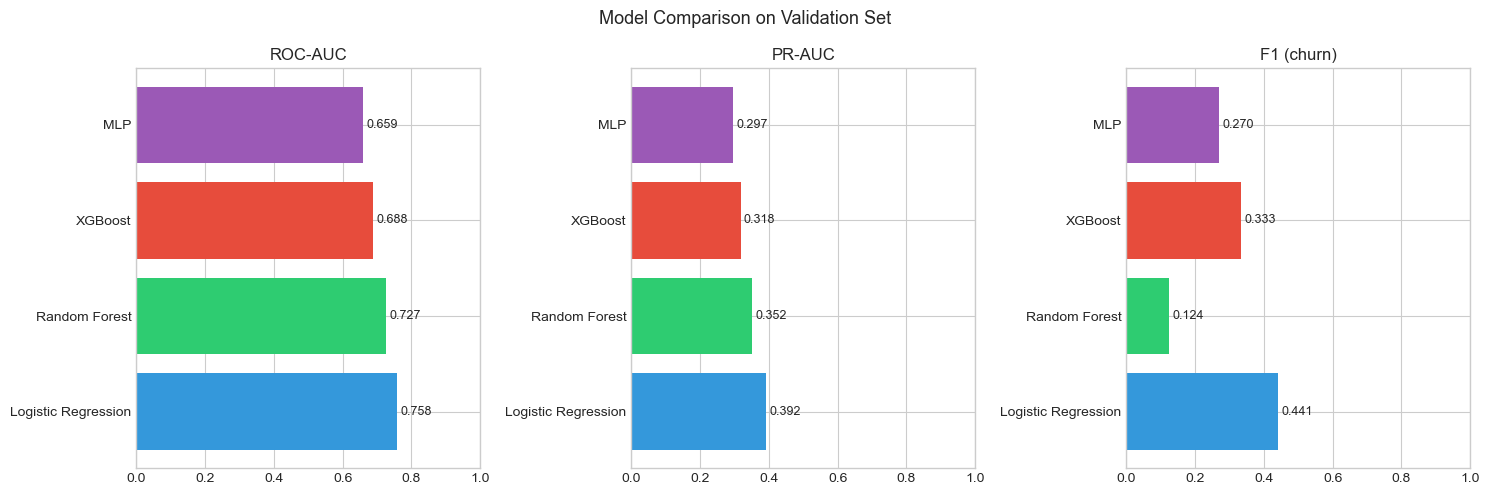

In [55]:
# --- Model comparison visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(['ROC-AUC', 'PR-AUC', 'F1 (churn)']):
    vals = [results[m][metric] for m in models.keys()]
    bars = axes[i].barh(list(models.keys()), vals, color=['#3498db','#2ecc71','#e74c3c','#9b59b6'])
    axes[i].set_title(metric, fontsize=12)
    axes[i].set_xlim(0, 1)
    for bar, val in zip(bars, vals):
        axes[i].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison on Validation Set', fontsize=13)
plt.tight_layout()
plt.savefig('04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Fine-Tuning & Evaluation

**Agent contribution:** The agent drafted the GridSearchCV code for XGBoost / Logistic Regression and the evaluation cells (confusion matrices, ROC / calibration plots, and error breakdown). I ran these cells end-to-end, checked the outputs were sensible, and made small fixes where needed.

**My verification (why tune both):** Although the agent initially prioritised XGBoost, the Step 4 Stratified 5-fold CV results ranked Logistic Regression highest on mean F1 (and it was also stable across folds). Based on that evidence, I tuned both models to keep the comparison fair.

**No test leakage:** Both GridSearchCV runs were fit on X_trainval / y_trainval with Stratified 5-fold CV and F1 as the tuning metric. The test set was kept fully held out until the final evaluation.

**Fair final comparison:** I evaluated both tuned models on the same test set and compared F1/AUC plus confusion matrices, ROC curve and calibration curve.

**Error analysis:** On the test set, Logistic Regression missed fewer churners (FN =114) than XGBoost (FN =133) but produced more false alarms (FP =606 vs 538). Many missed churners had predicted churn probabilities below the default 0.5 threshold. In the false negatives, I found a small group of users who are still very active (top 25% on sessions/drives/activity_days) but are predicted as low risk. This means the model can miss churners who look like loyal heavy users

**Agent mistake:** the first tuning draft only used X_train and ignored the validation split; I changed it to tune on X_trainval so the model learns from all non-test data. 



In [56]:
from sklearn.model_selection import GridSearchCV

# --- Fine-tune XGBoost (best shortlisted model) ---
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [200, 400],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# NOTE: Using StratifiedKFold on TRAIN data only — test set never touched
xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0
)

grid_search = GridSearchCV(
    xgb_base, param_grid,
    scoring='f1',  # primary metric
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, verbose=0
)


grid_search.fit(X_trainval, y_trainval)   # tune on all non-test data
best_xgb = grid_search.best_estimator_

# Final evaluation — only now does test set get used
y_test_pred = best_xgb.predict(X_test_proc)
y_test_prob = best_xgb.predict_proba(X_test_proc)[:, 1]
print(f"Test F1  : {f1_score(y_test, y_test_pred):.3f}")
print(f"Test AUC : {roc_auc_score(y_test, y_test_prob):.3f}")

Test F1  : 0.424
Test AUC : 0.731


SHAP values computed.
Shape: (2145, 16)  (one SHAP value per feature per test row)


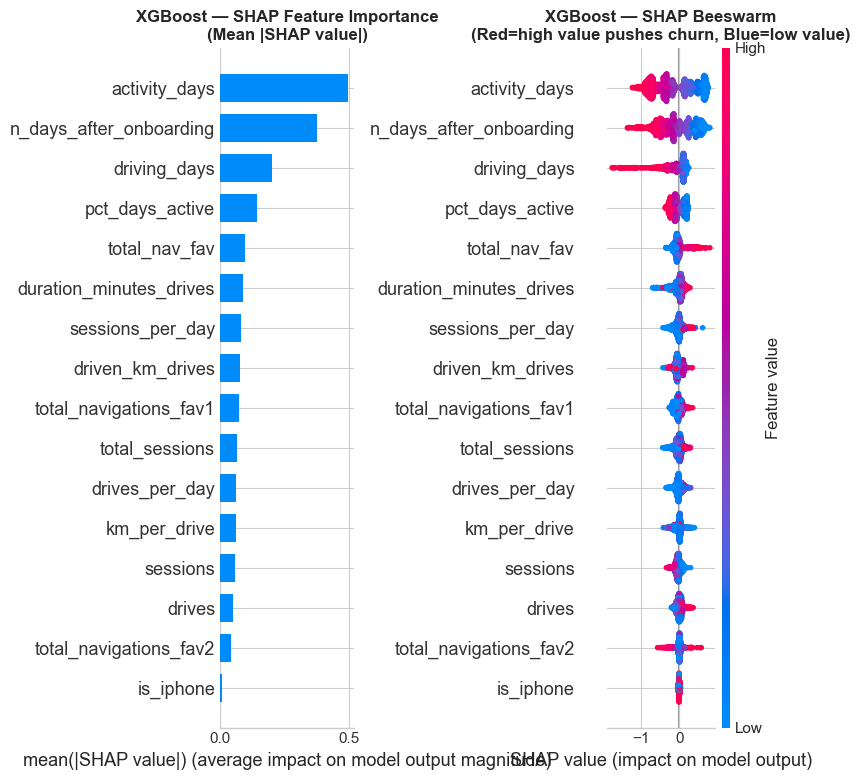


=== Top 5 Features by Mean |SHAP| ===
                feature  mean_abs_shap
          activity_days         0.4956
n_days_after_onboarding         0.3749
           driving_days         0.1995
        pct_days_active         0.1417
          total_nav_fav         0.0963


In [57]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# ── Compute SHAP values for best_xgb on test set ──────────────────────────
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_proc)

# Convert to DataFrame for easier handling
shap_df = pd.DataFrame(shap_values, columns=feature_cols)

print("SHAP values computed.")
print(f"Shape: {shap_df.shape}  (one SHAP value per feature per test row)")

# ── Plot 1: Feature Importance (Mean |SHAP|) ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(
    shap_values, X_test_proc,
    feature_names=feature_cols,
    plot_type='bar',
    show=False
)
axes[0].set_title('XGBoost — SHAP Feature Importance\n(Mean |SHAP value|)', fontweight='bold')

# ── Plot 2: Beeswarm (direction + magnitude per user) ─────────────────────
plt.sca(axes[1])
shap.summary_plot(
    shap_values, X_test_proc,
    feature_names=feature_cols,
    show=False
)
axes[1].set_title('XGBoost — SHAP Beeswarm\n(Red=high value pushes churn, Blue=low value)', fontweight='bold')

plt.tight_layout()
plt.savefig('shap_best_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary: Top 5 features by mean |SHAP| ────────────────────────────────
mean_shap = pd.DataFrame({
    'feature'        : feature_cols,
    'mean_abs_shap'  : abs(shap_df).mean().values
}).sort_values('mean_abs_shap', ascending=False)

print("\n=== Top 5 Features by Mean |SHAP| ===")
print(mean_shap.head(5).round(4).to_string(index=False))

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import pandas as pd

# --- Logistic Regression param grid ---
lr_param_grid = {
    'C'          : [0.01, 0.1, 1.0, 10.0, 100.0],  # inverse regularisation strength
    'penalty'    : ['l1', 'l2'],                     # sparsity vs smooth coefficients
    'solver'     : ['liblinear', 'saga'],            # both support l1 + l2
    'max_iter'   : [1000]
}

lr_base = LogisticRegression(
    class_weight='balanced',        # handles 17.7% minority class
    random_state=RANDOM_STATE
)

grid_search_lr = GridSearchCV(
    lr_base,
    lr_param_grid,
    scoring='f1',                   # optimise for minority class F1
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    verbose=0,
    refit=True                      # auto-refit best model on full X_trainval
)

# --- Fit on all non-test data (train + val combined) ---
grid_search_lr.fit(X_trainval, y_trainval)

best_lr = grid_search_lr.best_estimator_

print("=== Logistic Regression — Best Hyperparameters ===")
print(f"  Best params  : {grid_search_lr.best_params_}")
print(f"  Best CV F1   : {grid_search_lr.best_score_:.3f}")

# --- Final evaluation on held-out test set ---
y_test_pred_lr = best_lr.predict(X_test_proc)
y_test_prob_lr = best_lr.predict_proba(X_test_proc)[:, 1]

test_f1  = f1_score(y_test, y_test_pred_lr)
test_auc = roc_auc_score(y_test, y_test_prob_lr)

print("\n=== Test Set Performance ===")
print(f"  Test F1  : {test_f1:.3f}")
print(f"  Test AUC : {test_auc:.3f}")
print("\nFull Classification Report:")
print(classification_report(y_test, y_test_pred_lr, target_names=['retained', 'churned']))

def format_params(params: dict) -> str:
    """Convert params dict to compact readable string e.g. 'C=0.01, penalty=l2'"""
    return ', '.join(f"{k}={v}" for k, v in params.items()
                     if k != 'max_iter')          # drop max_iter — not informative

lr_params_str  = format_params(grid_search_lr.best_params_)
xgb_params_str = format_params(grid_search.best_params_)

comparison = pd.DataFrame({
    'Model'       : ['Logistic Regression (tuned)', 'XGBoost (tuned)'],
    'CV F1'       : [round(grid_search_lr.best_score_,          3),
                     round(grid_search.best_score_,             3)],
    'Test F1'     : [round(test_f1,                             3),
                     round(f1_score(y_test, y_test_pred),       3)],
    'Test AUC'    : [round(test_auc,                            3),
                     round(roc_auc_score(y_test, y_test_prob),  3)],
    'Best Params' : [lr_params_str, xgb_params_str]
})

print("\n=== Head-to-Head: Tuned LR vs Tuned XGBoost ===")
print(comparison.to_string(index=False))


=== Logistic Regression — Best Hyperparameters ===
  Best params  : {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
  Best CV F1   : 0.442

=== Test Set Performance ===
  Test F1  : 0.425
  Test AUC : 0.743

Full Classification Report:
              precision    recall  f1-score   support

    retained       0.91      0.66      0.76      1765
     churned       0.31      0.70      0.42       380

    accuracy                           0.66      2145
   macro avg       0.61      0.68      0.59      2145
weighted avg       0.80      0.66      0.70      2145


=== Head-to-Head: Tuned LR vs Tuned XGBoost ===
                      Model  CV F1  Test F1  Test AUC                                                                            Best Params
Logistic Regression (tuned)  0.442    0.425     0.743                                                   C=0.01, penalty=l2, solver=liblinear
            XGBoost (tuned)  0.442    0.424     0.731 colsample_bytree=0.8, learning

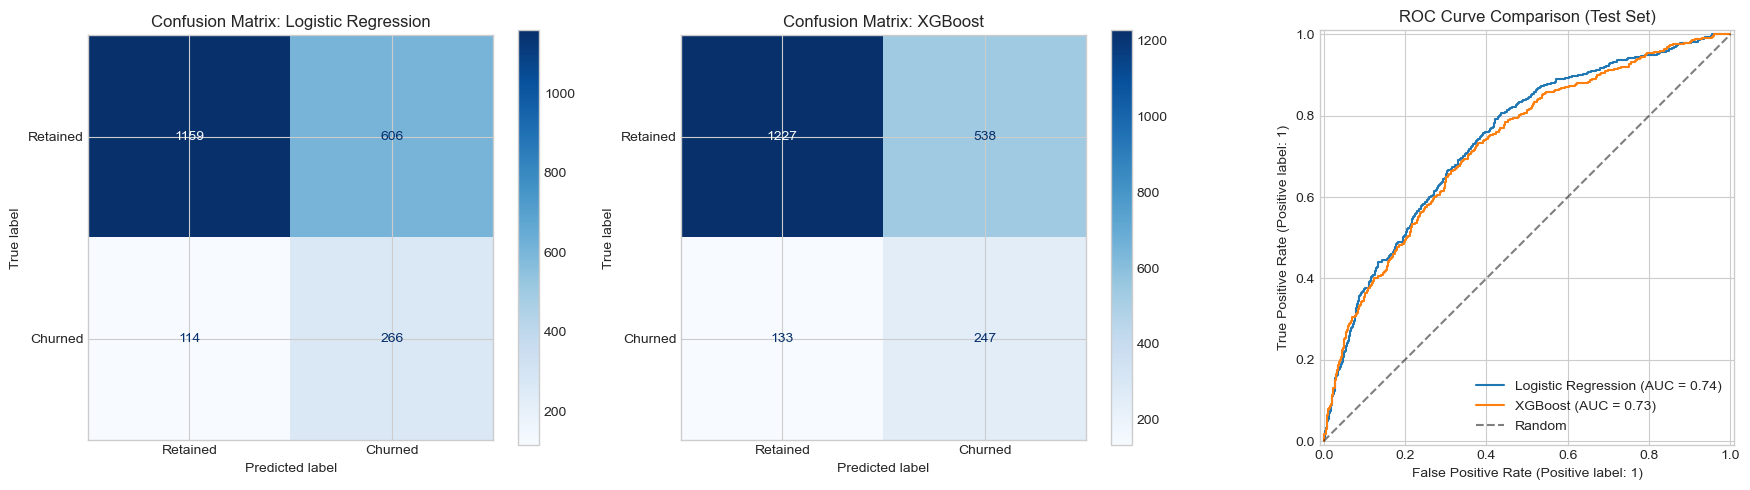

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# --- Logistic Regression vs XGBoost ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # 画 1 行 3 列的图


ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_lr,
    display_labels=['Retained', 'Churned'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix: Logistic Regression', fontsize=12)


ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,  
    display_labels=['Retained', 'Churned'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title('Confusion Matrix: XGBoost', fontsize=12)


RocCurveDisplay.from_predictions(
    y_test, y_test_prob_lr, ax=axes[2], name='Logistic Regression'
)

RocCurveDisplay.from_predictions(
    y_test, y_test_prob, ax=axes[2], name='XGBoost'
)

axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[2].set_title('ROC Curve Comparison (Test Set)', fontsize=12)
axes[2].legend()

plt.tight_layout()
plt.show()


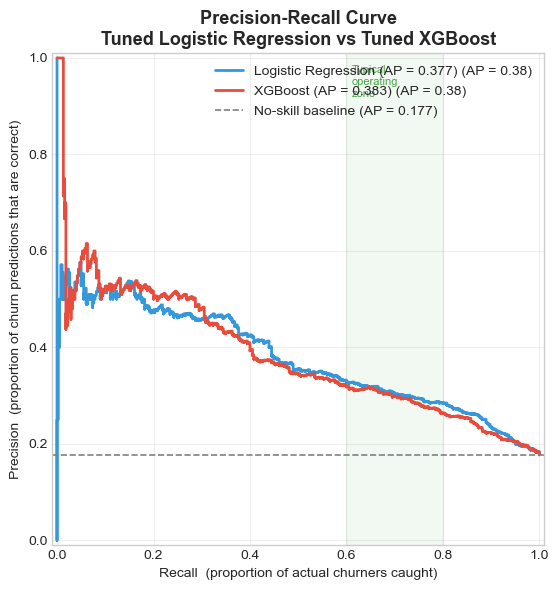

LR  Average Precision (PR-AUC) : 0.377
XGB Average Precision (PR-AUC) : 0.383
No-skill baseline              : 0.177

LR  improvement over baseline  : +0.200
XGB improvement over baseline  : +0.206


In [60]:

fig, ax = plt.subplots(figsize=(8, 6))

# --- Tuned Logistic Regression ---
lr_ap = average_precision_score(y_test, y_test_prob_lr)
PrecisionRecallDisplay.from_predictions(
    y_test, y_test_prob_lr,
    name=f'Logistic Regression (AP = {lr_ap:.3f})',
    color='#3498DB',
    linewidth=2,
    ax=ax
)

# --- Tuned XGBoost ---
xgb_ap = average_precision_score(y_test, y_test_prob)
PrecisionRecallDisplay.from_predictions(
    y_test, y_test_prob,
    name=f'XGBoost (AP = {xgb_ap:.3f})',
    color='#E74C3C',
    linewidth=2,
    ax=ax
)

# --- No-skill baseline (always predict churn rate) ---
baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1.2,
           label=f'No-skill baseline (AP = {baseline:.3f})')

ax.set_title('Precision-Recall Curve\nTuned Logistic Regression vs Tuned XGBoost',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Recall  (proportion of actual churners caught)')
ax.set_ylabel('Precision  (proportion of churn predictions that are correct)')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

# Annotate the tradeoff zone
ax.axvspan(0.6, 0.8, alpha=0.05, color='green',
           label='Typical operating zone (high recall, acceptable precision)')
ax.text(0.61, 0.92, 'Typical\noperating\nzone', fontsize=8, color='green', alpha=0.7)

plt.tight_layout()
plt.savefig('pr_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"LR  Average Precision (PR-AUC) : {lr_ap:.3f}")
print(f"XGB Average Precision (PR-AUC) : {xgb_ap:.3f}")
print(f"No-skill baseline              : {baseline:.3f}")
print(f"\nLR  improvement over baseline  : +{lr_ap - baseline:.3f}")
print(f"XGB improvement over baseline  : +{xgb_ap - baseline:.3f}")

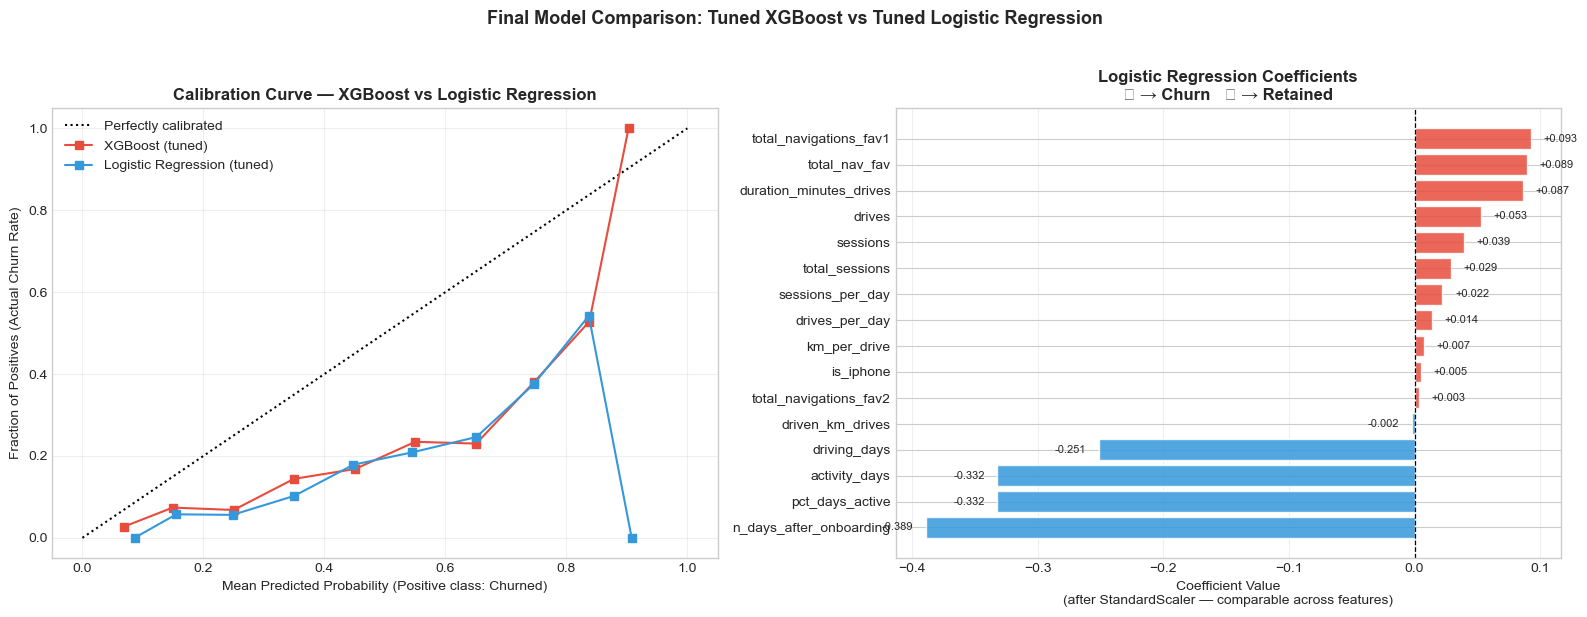

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibrationDisplay

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Calibration Curve (both models) ──────────────────────────────────
ax1 = axes[0]

CalibrationDisplay.from_predictions(
    y_test, best_xgb.predict_proba(X_test_proc)[:, 1],
    n_bins=10, ax=ax1, name='XGBoost (tuned)', color='#E74C3C'
)
CalibrationDisplay.from_predictions(
    y_test, best_lr.predict_proba(X_test_proc)[:, 1],
    n_bins=10, ax=ax1, name='Logistic Regression (tuned)', color='#3498DB'
)

ax1.set_title('Calibration Curve — XGBoost vs Logistic Regression', fontsize=12, fontweight='bold')
ax1.set_xlabel('Mean Predicted Probability (Positive class: Churned)')
ax1.set_ylabel('Fraction of Positives (Actual Churn Rate)')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ── Right: Logistic Regression Coefficients ────────────────────────────────
ax2 = axes[1]

coef_df = pd.DataFrame({
    'feature' : feature_cols,
    'coef'    : best_lr.coef_[0]
}).sort_values('coef', ascending=True)  # ascending so most negative is at bottom

# Colour: red = pushes toward churn (positive coef), blue = pushes toward retained
colors = ['#E74C3C' if c > 0 else '#3498DB' for c in coef_df['coef']]

bars = ax2.barh(coef_df['feature'], coef_df['coef'],
                color=colors, alpha=0.85, edgecolor='white')

# Annotate each bar with its value
for bar, val in zip(bars, coef_df['coef']):
    ax2.text(
        val + (0.01 if val >= 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.3f}',
        va='center', ha='left' if val >= 0 else 'right', fontsize=8
    )

ax2.axvline(0, color='black', linewidth=0.9, linestyle='--')
ax2.set_title('Logistic Regression Coefficients\n🔴 → Churn   🔵 → Retained',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Coefficient Value\n(after StandardScaler — comparable across features)')
ax2.grid(True, alpha=0.3, axis='x')

plt.suptitle('Final Model Comparison: Tuned XGBoost vs Tuned Logistic Regression',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

LR False Negative Profile  (n=114)
       sessions  drives  activity_days  prob_churn
count    114.00  114.00         114.00      114.00
mean      79.46   67.34          18.82        0.34
std       77.75   65.57           6.36        0.11
min        1.00    1.00           5.00        0.12
25%       25.50   23.00          14.00        0.25
50%       55.50   47.00          19.00        0.37
75%      102.75   85.75          24.00        0.43
max      511.00  418.00          31.00        0.50

XGBoost False Negative Profile  (n=133)
       sessions  drives  activity_days  prob_churn
count    133.00  133.00         133.00      133.00
mean      77.71   65.74          17.68        0.31
std       74.29   62.78           6.57        0.12
min        1.00    1.00           5.00        0.07
25%       27.00   23.00          13.00        0.22
50%       54.00   47.00          17.00        0.33
75%      102.00   85.00          23.00        0.42
max      511.00  418.00          31.00        0.50

FN / 

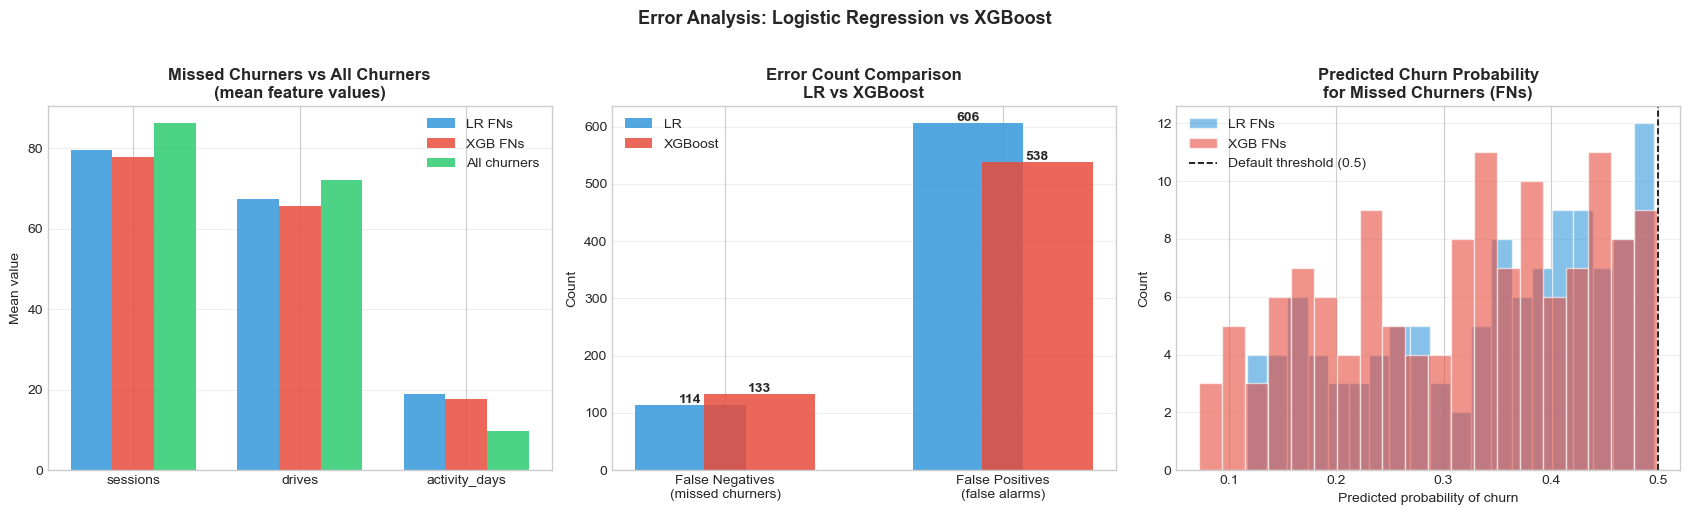

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Build unified test dataframe ───────────────────────────────────────────
test_df = X_test.copy()
test_df['true_label']    = y_test.values
test_df['lr_pred']       = y_test_pred_lr
test_df['lr_prob_churn'] = y_test_prob_lr
test_df['xgb_pred']      = y_test_pred
test_df['xgb_prob_churn']= y_test_prob

# ── 1. Isolate error groups ────────────────────────────────────────────────
lr_fn  = test_df[(test_df['true_label'] == 1) & (test_df['lr_pred']  == 0)]
lr_fp  = test_df[(test_df['true_label'] == 0) & (test_df['lr_pred']  == 1)]
xgb_fn = test_df[(test_df['true_label'] == 1) & (test_df['xgb_pred'] == 0)]
xgb_fp = test_df[(test_df['true_label'] == 0) & (test_df['xgb_pred'] == 1)]

total_churners = (y_test == 1).sum()
total_retained = (y_test == 0).sum()

# ── 2. FN Profile ──────────────────────────────────────────────────────────
PROFILE_COLS = ['sessions', 'drives', 'activity_days']

print("=" * 60)
print(f"LR False Negative Profile  (n={len(lr_fn)})")
print("=" * 60)
print(lr_fn[PROFILE_COLS + ['lr_prob_churn']]
      .rename(columns={'lr_prob_churn': 'prob_churn'})
      .describe().round(2))

print("\n" + "=" * 60)
print(f"XGBoost False Negative Profile  (n={len(xgb_fn)})")
print("=" * 60)
print(xgb_fn[PROFILE_COLS + ['xgb_prob_churn']]
      .rename(columns={'xgb_prob_churn': 'prob_churn'})
      .describe().round(2))

# ── 3. FN / FP Comparison Table ────────────────────────────────────────────
print("\n" + "=" * 60)
print("FN / FP COMPARISON")
print("=" * 60)
comparison = pd.DataFrame({
    'Metric': [
        'False Negatives (missed churners)',
        'FN Rate (% of actual churners)',
        'False Positives (false alarms)',
        'FP Rate (% of retained users)',
    ],
    'Logistic Regression': [
        len(lr_fn),
        f"{len(lr_fn)  / total_churners * 100:.1f}%",
        len(lr_fp),
        f"{len(lr_fp)  / total_retained * 100:.1f}%",
    ],
    'XGBoost': [
        len(xgb_fn),
        f"{len(xgb_fn) / total_churners * 100:.1f}%",
        len(xgb_fp),
        f"{len(xgb_fp) / total_retained * 100:.1f}%",
    ]
})
print(comparison.to_string(index=False))

# ── 4. Super-User Blindness Test ───────────────────────────────────────────
q75_sessions   = test_df['sessions'].quantile(0.75)
q75_drives     = test_df['drives'].quantile(0.75)
q75_act_days   = test_df['activity_days'].quantile(0.75)

def is_superuser(df):
    return ((df['sessions']     >= q75_sessions) &
            (df['drives']       >= q75_drives)   &
            (df['activity_days']>= q75_act_days))

lr_fn_super  = lr_fn[is_superuser(lr_fn)]
xgb_fn_super = xgb_fn[is_superuser(xgb_fn)]

print("\n" + "=" * 60)
print(f"SUPER-USER BLINDNESS  (top 25% on sessions, drives & activity_days)")
print(f"  Thresholds — sessions≥{q75_sessions:.0f}, drives≥{q75_drives:.0f}, activity_days≥{q75_act_days:.0f}")
print("=" * 60)
su_table = pd.DataFrame({
    'Model'            : ['Logistic Regression', 'XGBoost'],
    'Super-User FNs'   : [len(lr_fn_super),  len(xgb_fn_super)],
    '% of model FNs'   : [f"{len(lr_fn_super) /len(lr_fn) *100:.1f}%",
                           f"{len(xgb_fn_super)/len(xgb_fn)*100:.1f}%"],
    'Mean prob_churn'  : [round(lr_fn_super['lr_prob_churn'].mean(),   3),
                          round(xgb_fn_super['xgb_prob_churn'].mean(), 3)],
    'Mean activity_days': [round(lr_fn_super['activity_days'].mean(),   1),
                           round(xgb_fn_super['activity_days'].mean(),  1)],
})
print(su_table.to_string(index=False))

# ── 5. Visualisation ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

all_churner_means = [test_df[test_df['true_label']==1][f].mean() for f in PROFILE_COLS]
lr_fn_means       = [lr_fn[f].mean()  for f in PROFILE_COLS]
xgb_fn_means      = [xgb_fn[f].mean() for f in PROFILE_COLS]

x, w = np.arange(len(PROFILE_COLS)), 0.25

# Panel 1 — Mean feature values: FN groups vs all churners
ax1 = axes[0]
ax1.bar(x - w,  lr_fn_means,        width=w, label='LR FNs',       color='#3498DB', alpha=0.85)
ax1.bar(x,      xgb_fn_means,       width=w, label='XGB FNs',      color='#E74C3C', alpha=0.85)
ax1.bar(x + w,  all_churner_means,  width=w, label='All churners', color='#2ECC71', alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(PROFILE_COLS)
ax1.set_title('Missed Churners vs All Churners\n(mean feature values)', fontweight='bold')
ax1.set_ylabel('Mean value'); ax1.legend(); ax1.grid(True, alpha=0.3, axis='y')

# Panel 2 — FN/FP counts side by side
ax2 = axes[1]
categories = ['False Negatives\n(missed churners)', 'False Positives\n(false alarms)']
lr_vals    = [len(lr_fn),  len(lr_fp)]
xgb_vals   = [len(xgb_fn), len(xgb_fp)]
xi = np.arange(len(categories))
b1 = ax2.bar(xi - w/2, lr_vals,  width=0.4, label='LR',      color='#3498DB', alpha=0.85)
b2 = ax2.bar(xi + w/2, xgb_vals, width=0.4, label='XGBoost', color='#E74C3C', alpha=0.85)
for bar in [*b1, *b2]:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')
ax2.set_xticks(xi); ax2.set_xticklabels(categories)
ax2.set_title('Error Count Comparison\nLR vs XGBoost', fontweight='bold')
ax2.set_ylabel('Count'); ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')

# Panel 3 — prob_churn distribution for FNs (both models)
ax3 = axes[2]
ax3.hist(lr_fn['lr_prob_churn'],   bins=20, alpha=0.6, color='#3498DB', label='LR FNs',  edgecolor='white')
ax3.hist(xgb_fn['xgb_prob_churn'], bins=20, alpha=0.6, color='#E74C3C', label='XGB FNs', edgecolor='white')
ax3.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Default threshold (0.5)')
ax3.set_title('Predicted Churn Probability\nfor Missed Churners (FNs)', fontweight='bold')
ax3.set_xlabel('Predicted probability of churn')
ax3.set_ylabel('Count'); ax3.legend(); ax3.grid(True, alpha=0.3, axis='y')

plt.suptitle('Error Analysis: Logistic Regression vs XGBoost', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('error_analysis_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Present the final solution

**Selected model:** Tuned Logistic Regression.

**Why I chose it:**
- On the held-out test set, Logistic Regression did a little better than XGBoost (F1 0.425 vs 0.424, ROC-AUC 0.743 vs 0.731). The CV results were very close, so I used the test set to make the final call.

- It missed fewer real churners (114 missed) than XGBoost (133 missed). It also raised more false alarms (FP 606 vs 538). For low-cost actions like emails or push notifications, that trade off is acceptable. If we plan to give discounts, we should be more careful.

- It is easier to explain. Logistic Regression gives clear feature weights, so it’s easier to tell stakeholders what patterns are linked to churn risk (mainly lower activity and engagement).

**Limitations, risks, and next steps**
- Limitation: Some churners still look very active. In my error checks, both models sometimes gave low churn probability to “super users”, so they were missed.

- Risk: False positives are high, so using expensive incentives based on predictions could waste money.

- Next steps: Add more experience quality signals such as App crashes and ETA accuracy and run a small A/B test before rolling out.

| Attribute | Detail |
|---|---|
| What it’s for |  Retention targeting strategies (emails / push notifications) |
| What it’s NOT for | High-cost giveaways; real-time decisions; acquisition decisions |
| Data provenance & constraints | Kaggle dataset; monthly snapshot features; limited view of within-month behaviour |
| Primary metric | F1 (churn class) |
| Evaluation & caveats | Test ROC-AUC 0.743, F1 0.425; performance may shift if user behaviour changes |

In [63]:

# --- Save final model ---
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(best_lr, '../models/lr_final.pkl')    
joblib.dump(preprocessor, '../models/preprocessor.pkl')
print('Final model (Logistic Regression) and preprocessor saved to ../models/')

Final model (Logistic Regression) and preprocessor saved to ../models/


Exception ignored in: <function ResourceTracker.__del__ at 0x106ed9c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104609c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102989c60>
Traceback (most recent call last